In [1]:
%load_ext autoreload
%autoreload 2
import cooler
import pandas as pd

res = 12800

cool_nc18 = cooler.Cooler(f'./cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_nc14 = cooler.Cooler(f'./cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_s10 = cooler.Cooler(f'./cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')

In [2]:
%load_ext autoreload
%autoreload
import scanpy as sc
import sys

sys.path.append('./code2')

from hic_zscore_functions import make_obs_exp_intra
from aux_functions import *
from plotting_functions import *

sc.settings.set_figure_params(dpi=80, color_map='coolwarm', frameon=True)
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"axes.grid.axis" : 'both'})
plt.rcParams.update({"axes.grid" : True})

plt.rcParams.update({
    'axes.labelsize': 14,       # x and y labels' font size
    'xtick.labelsize': 8,      # x tick labels' font size
    'ytick.labelsize': 8,      # y tick labels' font size
    'axes.titlesize': 14,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'legend.fontsize': 6,      # Legend font size
})
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'axes.labelsize': 8,       # x and y labels' font size
    'xtick.labelsize': 6,      # x tick labels' font size
    'ytick.labelsize': 6,      # y tick labels' font size
    'axes.titlesize': 10,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'xtick.major.pad' : 2,
    'ytick.major.pad' : 2,

})
plt.rcParams['axes.linewidth'] = .25
plt.rcParams['xtick.major.width'] = .25
plt.rcParams['ytick.major.width'] = .25
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['grid.linewidth'] = .25

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['svg.fonttype'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def subset_df_by_bedtool(df, bed, c=False):
    if c == False:
        has_bed = (index_to_bedtool(df.index).intersect(bed, c=True).to_dataframe(header=None).iloc[:, -1]>0).values
        return df.loc[has_bed], df.loc[~has_bed]
    else:
        has_bed = (index_to_bedtool(df.index).intersect(bed, c=True).to_dataframe(header=None).iloc[:, -1]).values
        return has_bed

In [4]:
color_dict = {
    'nc1-8' : 'blue',
    'nc14' : 'red',
    's10-12' : 'black',
}

In [5]:
from config import rgb_to_cluster, cluster_to_rgb, load_cses

all_loop_anchors = pd.read_csv('/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data/browser_tracks/all_stages.loop_anchors_and_both_with_cluster_colors.scores=plain.bed',
                      sep='\t', header=None)

all_loop_anchors['cluster'] = all_loop_anchors[8].apply(rgb_to_cluster.get)
all_cses = load_cses()

In [6]:
genes = pbt.BedTool('../for_annotations/dmel-6.39.gtf').filter(lambda x: x[2]=='gene'
                ).filter(lambda x: 'pre-mod' not in x[-1]
                ).filter(lambda x: '5Sr' not in x[-1]
                ).filter(lambda x: 'sno' not in x[-1]).saveas(
                ).saveas().to_dataframe()

genes['gene_name'] = [x.split('"')[-2] for x in genes['attributes']]
genes = genes[genes['seqname'].isin(['3L', '2L', '3R', '2R',])]
genes = genes[['seqname', 'start', 'end', 'gene_name', 'strand']]

genes.index = df_to_index(genes.iloc[:, :3])

a0, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==0]))
a1, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==1]))
a2, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==2]))
a3, _ = subset_df_by_bedtool(genes, index_to_bedtool(all_cses.index[all_cses['cluster']==3]))

genes['cluster0'] = genes.index.isin(a0.index)
genes['cluster1'] = genes.index.isin(a1.index)
genes['cluster2'] = genes.index.isin(a2.index)
genes['cluster3'] = genes.index.isin(a3.index)

genes.loc[genes['cluster0']>0, 'cluster'] = 0
genes.loc[genes['cluster1']>0, 'cluster'] = 1
genes.loc[genes['cluster2']>0, 'cluster'] = 2
genes.loc[genes['cluster3']>0, 'cluster'] = 3

genes_plus = genes[genes['strand'] == '+']
genes_minus = genes[genes['strand'] == '+']
genes_minus['start'] = genes_minus['end']

all_genes = pd.concat([genes_plus, genes_minus], axis=0)

/tmp/ipykernel_2965437/3004970927.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes_minus['start'] = genes_minus['end']


In [7]:
import bbi

pref = '/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/chip_seq_sra_peaks/'
bbi_bws = {
    'RNA_pol2' : bbi.open(pref + 'SRP016560.2-3hr_embryos.RNA_polymerase_II.None.False.False_bdgcmp.sorted.bw'),
    'Trl' : bbi.open(pref + 'SRP058444.2-4hr_embryos.Trl.None.False.False_bdgcmp.sorted.bw'),
    'BEAF-32' : bbi.open(pref + 'SRP007592.Kc167.BEAF-32.None.False.False_bdgcmp.sorted.bw'),
    'suHw' : bbi.open(pref + 'SRP007592.Kc167.suHw.None.False.False_bdgcmp.sorted.bw'),
    'H3K27ac' : bbi.open(pref + 'SRP044032.mitotic_cycle_14c-d.H3K27ac.None.False.False_bdgcmp.sorted.bw'),
    'H3K27me3' : bbi.open(pref + 'SRP044032.mitotic_cycle_14c-d.H3K27me3.None.False.False_bdgcmp.sorted.bw'),
    'Pc' : bbi.open(pref + 'SRP045520.4-12hr_embryos.Pc.None.False.False_bdgcmp.sorted.bw'),
    'GRO' : bbi.open('../tfs/bws/GSE41611_GRO_COMBINED.bw'),
    'RNA_pol2_1-2hr' : bbi.open(pref + 'SRP016560.1-2hr_embryos.RNA_polymerase_II.None.False.False_bdgcmp.sorted.bw'),
}

In [8]:
import numpy as np
import pandas as pd
import pypairix
import concurrent.futures

def extract_reads_within_locus(pairs_file, chrom, start, end, min_co = 120):
    vecs = {
        '++': pd.Series(0, index=range(0, end + 1 - start))
    }

    # Open the pairs file using pypairix
    tb = pypairix.open(pairs_file)
    
    chrom_end = int(pd.DataFrame(tb.get_chromsize()).set_index(0).loc[chrom][1])
    
    # Query the pairs data for reads within the specified region
    it = tb.query2D(chrom, 0, chrom_end, chrom, start, end)

    read_ids = set()
    # Iterate over the pairs and categorize them
    for record in it:
        # Extract start positions for both reads in the pair
        read_id = record[0]
        if read_id in read_ids:
            continue
        else:
            read_ids.add(read_id)
        read_start = int(record[2])
        mate_start = int(record[4])
        read_orientation = record[5]
        mate_orientation = record[6]
        # Skip pairs where the start of the first read is greater than or equal to the second read
        
        if (read_orientation == '+') and (mate_orientation == '+'):
            dist = mate_start - read_start        
            # Determine orientation and categorize based on read distances
            if min_co < dist < np.inf:
                if start <= read_start <= end:
                    vecs['++'].iloc[read_start - start] += 1
                if start <= mate_start <= end:
                    vecs['++'].iloc[mate_start - start] += 1

    # Return the vector for ++ orientation
    return vecs['++'].values


def process_locus(inp):
    (ind, sites, delta, pairs_file) = inp
    nucleosome_cutoffs6 = extract_reads_within_locus(
        pairs_file, 
        sites.iloc[ind, 0], sites.iloc[ind, 1] - delta, sites.iloc[ind, 1] + delta
    )
    return nucleosome_cutoffs6
    
def get_nucleosome_pileup(delta, sites, pairs_file):
    # Use ProcessPoolExecutor for parallel processing
    with concurrent.futures.ProcessPoolExecutor() as executor:
        # Map indices to the processing function
        results = list(executor.map(process_locus, zip(range(len(sites)), [sites]*len(sites),
                                                       [delta] * len(sites),
                                                       [pairs_file] * len(sites)
                                                      )))
    
    # Initialize the array for storing results
    all_nucleosomes1 = np.zeros((len(sites), delta + delta +1))
    
    # Populate the all_nucleosomes array with the processed results
    for ind, result in enumerate(results):
        a = result
        all_nucleosomes1[ind] = a
    return all_nucleosomes1




In [9]:
def extract_reads_within_locus(pairs_file, chrom, start, end, min_co = 120, max_co=400):
    vecs = {
        '++': pd.Series(0, index=range(0, end + 1 - start))
    }

    # Open the pairs file using pypairix
    tb = pypairix.open(pairs_file)
    
    chrom_end = int(pd.DataFrame(tb.get_chromsize()).set_index(0).loc[chrom][1])
    
    # Query the pairs data for reads within the specified region
    it = tb.query2D(chrom, 0, chrom_end, chrom, start, end)

    read_ids = set()
    # Iterate over the pairs and categorize them
    for record in it:
        # Extract start positions for both reads in the pair
        read_id = record[0]
        if read_id in read_ids:
            continue
        else:
            read_ids.add(read_id)
        read_start = int(record[2])
        mate_start = int(record[4])
        read_orientation = record[5]
        mate_orientation = record[6]
        # Skip pairs where the start of the first read is greater than or equal to the second read
        
        if (read_orientation == '+') and (mate_orientation == '+'):
            dist = mate_start - read_start        
            # Determine orientation and categorize based on read distances
            if min_co < dist < np.inf:
                if start <= read_start <= end:
                    vecs['++'].iloc[read_start - start] += 1
                if start <= mate_start <= end:
                    vecs['++'].iloc[mate_start - start] += 1

    # Return the vector for ++ orientation
    return vecs['++'].values


In [10]:
import pypairix
import numpy as np
import pandas as pd
import pyBigWig
import h5py

def process_chromosomes(pairs_file, chrom_list, output_filename="output.bw", min_co=0, save_as="bigwig"):
    """
    Process multiple chromosomes from a pairs file, categorizing read pairs by orientation.
    
    Parameters:
        pairs_file (str): Path to the indexed .pairs file.
        chrom_list (list): List of chromosome names.
        output_filename (str): Output file name (for BigWig or H5).
        min_co (int): Minimum distance between read pairs.
        save_as (str): Format to save ("bigwig" or "h5").
    """
    tb = pypairix.open(pairs_file)

    # Get chromosome sizes
    chrom_sizes = {
        chrom: int(pd.DataFrame(tb.get_chromsize()).set_index(0).loc[chrom][1])
        for chrom in chrom_list
    }

    # Store data for all chromosomes
    all_vecs = {chrom: {key: np.zeros(chrom_sizes[chrom] + 1, dtype=int) for key in ['++', '+-', '-+', '--']} 
                for chrom in chrom_list}

    # Read unique read pairs
    read_ids = set()

    for chrom in chrom_list:
        print(f"Processing {chrom}...")
        chrom_end = chrom_sizes[chrom]
        it = tb.query2D(chrom, 0, chrom_end, chrom, 0, chrom_end)
        c = 0 
        for record in it:
            read_id = record[0]
            if read_id in read_ids:
                continue
            read_ids.add(read_id)

            read_start = int(record[2])
            mate_start = int(record[4])
            read_orientation = record[5]
            mate_orientation = record[6]

            # Determine orientation
            orientation_key = read_orientation + mate_orientation
            dist = mate_start - read_start

            if min_co < dist < np.inf:
                if 0 <= read_start <= chrom_end:
                    all_vecs[chrom][orientation_key][read_start] += 1
                if 0 <= mate_start <= chrom_end:
                    all_vecs[chrom][orientation_key][mate_start] += 1
            c += 1

    # Save output
    if save_as == "bigwig":
        save_all_orientations_as_bigwig(all_vecs, chrom_sizes, output_filename)
    elif save_as == "h5":
        save_all_as_h5(all_vecs, output_filename)
    else:
        raise ValueError("Invalid format! Choose 'bigwig' or 'h5'.")

import pyBigWig

def save_all_orientations_as_bigwig(all_vecs, chrom_sizes, output_prefix):
    """
    Save each orientation ('++', '+-', '-+', '--') as a separate BigWig file.
    
    Parameters:
        all_vecs (dict): Dictionary containing read pair counts for each chromosome and orientation.
        chrom_sizes (dict): Dictionary of chromosome sizes.
        output_prefix (str): Prefix for the output filenames (e.g., "output" -> "output_++.bw").
    """
    orientations = ['++', '+-', '-+', '--']

    for orientation in orientations:
        output_filename = f"{output_prefix}_{orientation}.bw"
        bw = pyBigWig.open(output_filename, "w")
        bw.addHeader([(chrom, size) for chrom, size in chrom_sizes.items()])

        for chrom in all_vecs.keys():
            data = all_vecs[chrom][orientation]
            positions = np.nonzero(data)[0]
            values = data[positions]
            if len(positions) > 0:
                chrom_entry = list([chrom]*len(positions))
                chrom_entry = [str(x) for x in chrom_entry]
                start_entry = [int(x) for x in positions]
                value_entry = [float(x) for x in values]
                end_entry = [int(x)+1 for x in positions]
                bw.addEntries(chrom_entry, start_entry, values=value_entry, ends=end_entry)
        bw.close()
        print(f"Saved BigWig file: {output_filename}")

def save_all_as_h5(all_vecs, output_filename):
    """Save multiple chromosomes into a single HDF5 file."""
    with h5py.File(output_filename, "w") as f:
        for chrom, vecs in all_vecs.items():
            chrom_group = f.create_group(chrom)
            for orientation, data in vecs.items():
                chrom_group.create_dataset(orientation, data=data, compression="gzip")

    print(f"Saved HDF5 file: {output_filename}")

In [11]:
## Run this to generate the bigwig files
# chrom_list = ["3R", "3L", "2R", '2L', '4', 'X']  # Modify as needed
# process_chromosomes("/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data/merged_pairs/nc1-8_1_1+1_2+2_1+2_2.pairs.gz", 
#                     chrom_list, output_filename="nc1-8_mnase_from_pairs.bw", save_as="bigwig"
#                    )

# chrom_list = ["3R", "3L", "2R", '2L', '4', 'X']  # Modify as needed
# process_chromosomes("/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data/merged_pairs/nc14_1_1+1_2+2_1+2_2.pairs.gz", 
#                     chrom_list, output_filename="nc14_mnase_from_pairs.bw", save_as="bigwig"
#                    )

# chrom_list = ["3R", "3L", "2R", '2L', '4', 'X']  # Modify as needed
# process_chromosomes("/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/4DN_data/merged_pairs/s10-12_1_1+1_2+2_1+2_2.pairs.gz", 
#                     chrom_list, output_filename="s10-12_mnase_from_pairs.bw", save_as="bigwig"
#                    )

In [12]:

chrom_idx = (all_cses['chrom'] != 'Y')
nucleosome_values_cses = bbi.open('nc14_mnase_from_pairs.bw_++.bw').stackup(
                                                                              all_cses[chrom_idx]['chrom'],
                                                                              (all_cses[chrom_idx]['start'] - 1800),
                                                                              (all_cses[chrom_idx]['start'] + 1800 + 1),
                                        )

In [13]:
def make_figure_6a():
    n = nucleosome_values_cses.shape[1]//2
    xs = np.arange(-(n-200), n+1-200)
    fig, axs = init_subplots_exact(1, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    for u in np.unique(all_cses['cluster']):
        idx = all_cses[chrom_idx]['cluster'] == u
        vals = np.log2(1 + nucleosome_values_cses)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label = u, color = cluster_to_rgb[u])
        plt.fill_between(xs, v - v_sem, v + v_sem, color=cluster_to_rgb[u], alpha=0.3)    
    
    
    axs.set_xticks([-n, 0, n])
    axs.set_xticklabels(['-2kb', 'CSE', '+2kb'])
    plt.ylabel("Nucleosome coverage")
    plt.legend(bbox_to_anchor=(1, 1), title='Cluster', title_fontsize=6)
    plt.title("Nucleosome coverage")

In [14]:
def make_figure_6b():
    n = nucleosome_values_cses.shape[1]//2
    xs = np.arange(-(n-200), n+1-200)
    fig, axs = init_subplots_exact(1, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    for u in np.unique(all_cses['cluster']):
        idx = all_cses[chrom_idx]['cluster'] == u
        vals = np.log2(1 + nucleosome_values_cses)[idx]
        mean_vals = vals.mean(axis=0)[400:]
        sem_vals = scipy.ndimage.gaussian_filter1d(vals, sigma=20, axis=1).std(axis=0, ddof=1)[400:] / np.sqrt(vals.shape[0])
        v = scipy.ndimage.gaussian_filter1d(mean_vals, sigma=20)
        v_sem = scipy.ndimage.gaussian_filter1d(sem_vals, sigma=20)
        
        plt.plot(xs, v, label = u, color = cluster_to_rgb[u])
        plt.fill_between(xs, v - v_sem, v + v_sem, color=cluster_to_rgb[u], alpha=0.3)    
    
    
    axs.set_xticks([-n, 0, n])
    axs.set_xticklabels(['-2kb', 'CSE', '+2kb'])
    plt.ylabel("Nucleosome coverage")
    plt.legend(bbox_to_anchor=(1, 1), title='Cluster', title_fontsize=6)
    plt.title("Nucleosome coverage")

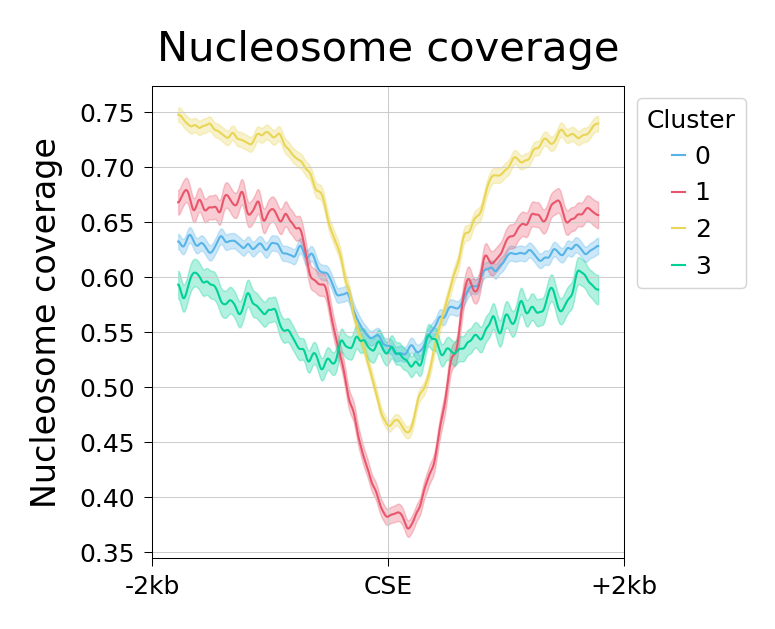

In [15]:
make_figure_6a()

In [16]:
def make_values():
    values = {}
    for key in bbi_bws.keys():
        v_plus = bbi_bws[key].stackup(genes_plus['seqname'], genes_plus['start'].astype(int)-1800, genes_plus['start'].astype(int)+1800)
        v_minus = bbi_bws[key].stackup(genes_minus['seqname'], genes_minus['start'].astype(int)-1800, genes_minus['start'].astype(int)+1800)
        v_minus = v_minus.T[::-1].T
        v = np.concatenate([v_plus, v_minus], axis=0)
        values[key] = pd.DataFrame(v)
    return values

values = make_values()

In [17]:
def get_nucleosome_values(bw, genes_plus, genes_minus):
    nucleosome_values_plus = bw.stackup( genes_plus['seqname'], (genes_plus['start'] - 1800), (genes_plus['start'] + 1800),)
    nucleosome_values_minus = bw.stackup( genes_minus['seqname'], (genes_minus['start'] - 1800), (genes_minus['start'] + 1800), ).T[::-1].T
    return np.concatenate([nucleosome_values_plus, nucleosome_values_minus[::-1]], axis=0)

In [18]:
from matplotlib.colors import LinearSegmentedColormap

# Define your four RGB colors (values should be between 0 and 1)
colors = list(cluster_to_rgb.values())

# Create a colormap from the four colors
cluster_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

def relabel_clusters(cluster, order):
    seen = set()
    newcluster = cluster.copy()
    for c, i in enumerate(cluster[order]):
        if i in seen:
            continue
        else:
            seen.add(i)
            newcluster[cluster==i] = len(seen)-1
    return newcluster

def get_o_clusts(tf_vals, n_clusters=4):
    if len(tf_vals.shape)==1:
        _, clust, _ = make_order_and_cluster_custom(tf_vals[:, None], n_clusters=n_clusters, method='ward', metric='euclidean')
        o = np.argsort(-tf_vals)
        clust = relabel_clusters(clust, o)
    else:
        o, clust, _ = make_order_and_cluster_custom(tf_vals, n_clusters=n_clusters, method='ward', metric='euclidean')
    return o, clust    

def make_mnase_plot(mat_dict, tf_vals, genes, n_clusters=4):
    o, clust = get_o_clusts(tf_vals, n_clusters=4)
    clust[tf_vals > np.nanquantile(tf_vals, .95)] = 0
    clust[(tf_vals < np.nanquantile(tf_vals, .95)) & (tf_vals > np.nanquantile(tf_vals, .9))] = 1
    clust[(tf_vals < np.nanquantile(tf_vals, .9)) & (tf_vals > np.nanquantile(tf_vals, .6))] = 2
    clust[(tf_vals < np.nanquantile(tf_vals, .6))] = 3
    
    n_plots = (len(mat_dict) + 1) * 2
    fig, axs = init_subplots_exact(n_plots, 2, fgsz=(4*.5, 4*.5), y_ratios = [.2, .9], x_ratios=[.1] + [.9]*len(mat_dict), 
                                   dpi = 80, xspace=1.2, yspace=1.05)
    
    
    newax = add_vector_to_L_axis(genes['cluster'].fillna(np.nan).values[o], axs[n_plots//2], cmap=cluster_cmap, aspect='auto',
                        x=-2, vmin = 0, vmax=3)
    newax.set_xticks([])
    newax.set_yticks([])

    axs[0].remove()

    for c, (key, mat) in enumerate(mat_dict.items()):
        c = c + 1
        mat = mat[:, 800:-800]
        dist = mat.shape[1]//2
        n = mat.shape[0]
        if c == 1:
            plt.sca(axs[n_plots//2])
            axs[n_plots//2].matshow(clust[o][:, None], aspect='auto', cmap='tab20', vmin=0, vmax=20, zorder=3, extent=[-dist, dist, n, 0],
                                   rasterized=True)
            axs[n_plots//2].set_xticks([])
            axs[n_plots//2].set_yticks([0, n])    

        if key == 'MNase Coverage':
            m = scipy.ndimage.gaussian_filter(np.log2(1+mat).astype(float)[o], sigma=8)
            vmax = 10
        else:
            m = scipy.ndimage.gaussian_filter(np.log2(1+mat).astype(float)[o], sigma=4)
            vmax=None
    
        plt.sca(axs[c+n_plots//2])
        axs[c+n_plots//2].matshow(m, aspect='auto', cmap='gist_heat_r', zorder=3, extent=[-dist, dist, n, 0],
                                 vmax=vmaxdict[key][1],
                                 vmin=vmaxdict[key][0])
        for u in range(6):
            idx = (clust == u)
            if key == 'MNase Coverage':
                v = scipy.ndimage.gaussian_filter1d(np.nanmean(np.log2(1+mat[idx]), axis=0), sigma = 8)
            else:
                v = np.nanmean(np.log2(1+mat[idx]), axis=0)
    
            axs[c].plot(v, color=sns.color_palette('tab20')[u], linewidth=2)
            axs[c].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
        axs[c+n_plots//2].set_yticks([])
        axs[c].set_title(key)
    
    for ax in axs[-n_plots//2+1:]:
        ax.set_xticks([-dist, 0, dist])
        ax.set_xticklabels([f'{-int(dist//1e3)}kb', f'TSS', f'{int(dist//1e3)}kb'])
        ax.tick_params(bottom=True, labelbottom=True, top=False, labeltop=False)
        
    for ax in axs:
        ax.grid(True)    
    return clust, o, fig

def add_vector_to_L_axis(vector, ax, ignore_set=[], bins=1000, x=-1, 
                     roundby = -5, label_for_title='', ylimdict = {}, cmap=None, **kwargs):
    newaxs = []
    newax1 = ax.inset_axes(transform=ax.transAxes, bounds = (x, 0, 1, 1))
    newax1.matshow(vector[:, None], cmap=cmap, **kwargs)
    return newax1

In [21]:
nucleosome_values_nc14 = get_nucleosome_values(bbi.open('nc14_mnase_from_pairs.bw_++.bw'), genes_plus, genes_minus)

In [28]:
mat_dict_nc14 = {
    'MNase Coverage' : nucleosome_values_nc14,
    'Trl' : values['Trl'].values,
    'RNA Pol2' : values['RNA_pol2'].values,
    'BEAF-32' : values['BEAF-32'].values,
    'Pc' : values['Pc'].values,
    'suHw' : values['suHw'].values,
    'H3K27ac' : values['H3K27ac'].values,
    'H3K27me3' : values['H3K27me3'].values,
}
vmaxdict = {
    'MNase Coverage' : [0.6, 1.5],
    'Trl' : [.75, 6],
    'RNA Pol2' : [.75, 8],
    'BEAF-32' : [.75, 8],
    'suHw' : [.75, 3],
    'Pc' : [.75, 4],
    'H3K27ac' : [.75, 5],
    'H3K27me3' : [.75, 5],
}


In [29]:
def make_figure_6b():    
    trl_vals = np.log2(1+np.nanmean(values['RNA_pol2'].iloc[:, 1500:2000], axis=1))
    clust_pol2, o, fig = make_mnase_plot(mat_dict_nc14, trl_vals, all_genes)
    fig.savefig('./new_figures/fig6/pol2_ordering_pileup.svg', bbox_inches='tight')
    
    trl_vals = np.log2(1+np.nanmean(values['Trl'].iloc[:, 1500:2000], axis=1))
    clust_trl, o_trl, fig = make_mnase_plot(mat_dict_nc14, trl_vals, all_genes)
    fig.savefig('./new_figures/fig6/gaf_ordering_pileup.svg', bbox_inches='tight')
    
    trl_vals = np.log2(1+np.nanmean(values['BEAF-32'].iloc[:, 1500:2000], axis=1))
    clust_beaf, o, fig = make_mnase_plot(mat_dict_nc14, trl_vals, all_genes)
    fig.savefig('./new_figures/fig6/beaf-32_ordering_pileup.svg', bbox_inches='tight')
    return clust_pol2, clust_trl, clust_beaf

In [ ]:
clust_pol2, clust_trl, clust_beaf = make_figure_6b()

4


/tmp/ipykernel_2965437/3939560209.py:74: RuntimeWarning: Mean of empty slice
  v = scipy.ndimage.gaussian_filter1d(np.nanmean(np.log2(1+mat[idx]), axis=0), sigma = 8)
/tmp/ipykernel_2965437/3939560209.py:76: RuntimeWarning: Mean of empty slice
  v = np.nanmean(np.log2(1+mat[idx]), axis=0)


4
4


In [ ]:
def make_figure_6c():
    idx_trl = clust_trl==0
    idx_dict = {
        'GAF' : clust_trl == 0,
        'BEAF-32' : clust_beaf == 0,
    }
    keys = ['MNase Coverage', 'RNA Pol2', 'Trl',  'BEAF-32', 'H3K27ac', 'H3K27me3', 'Pc']
    n = len(keys)
    cdict = {
        'GAF' : 'green',
        'BEAF-32' : 'red',
    }
    fig, axs = init_subplots_exact(n, n//2, fgsz=(2, .5), dpi = 150, yspace=1.4)
    for c, key in enumerate(keys):
        plt.sca(axs[c])
        mat = mat_dict_nc14[key]
        mat = mat[:, 800:-800]
        dist = mat.shape[1]//2
        # n = mat.shape[0]
        xs = np.arange(-1000, 1000)
        for key2, idx in idx_dict.items():
    
            mean_values = scipy.ndimage.gaussian_filter1d(np.nanmean(mat[idx], axis=0), sigma=20)[:2000]
            std_values = (np.nanstd(mat[idx], axis=0)/ np.sqrt(len(mat)))[:2000]
            # std_values = scipy.ndimage.gaussian_filter1d(np.nanstd(mat[idx], axis=0) / np.sqrt(len(idx)), sigma=20)[:2000]  # Standard error
            
            plt.plot(xs, mean_values, label=f'TSS with top 5% {key2}', linewidth=1, color=cdict[key2])
            plt.fill_between(xs, mean_values - 2*std_values, mean_values + 2*std_values, color=cdict[key2], alpha=0.3)
    
    
        plt.axvspan(-50, 50, color='lightgray', label='TSS')
        name = key
        if name == 'MNase Coverage':
            name = 'MNase'
        elif name == 'RNA Pol2':
            name = 'Pol2'
        elif name == 'Trl':
            name = 'GAF'
            
        plt.ylabel(name)
        axs[c].spines['top'].set_visible(False)
        axs[c].spines['right'].set_visible(False)
        axs[c].spines['right'].set_visible(False)
    
        if (c == n-1) or (c == n-2):
            plt.gca().tick_params(labelbottom=True)
        else:
            plt.gca().tick_params(labelbottom=False)
        plt.gca().set_xticks([-1000, -500, 0, 500, 1000])
        plt.gca().set_xticklabels(['-1kb', '-.5kb', 'TSS', '+.5kb', '+1kb'])
    plt.legend(bbox_to_anchor=(1, 1), loc = 'upper left')
    
    fig.savefig('./new_figures/fig6/phasing_at_top_TF_TSS.svg', bbox_inches='tight')    

In [ ]:
make_figure_6c()